In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, split_data, evaluate, save_model

In [8]:
df = pd.read_csv('data/processed/panel_final.csv')
print(f'{len(df):,} observations, {df.shape[1]} colonnes')

/tmp/ipykernel_6469/3958595456.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/panel_final.csv')


1,383,526 observations, 133 colonnes


In [9]:
x_train, x_test, y_train, y_test = split_data(df)

Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)


In [4]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight : {ratio:.1f}')

scale_pos_weight : 40.7


In [5]:
param_dist = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}

model_base = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
)

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=model_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

search.fit(x_train, y_train)

print(f'\nMeilleurs paramètres : {search.best_params_}')
print(f'Meilleure AUC en CV  : {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=200, subsample=0.8; total time=  10.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=500, subsample=0.7; total time=  23.4s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=200, subsample=0.8; total time=  24.1s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=200, subsample=0.8; total time=  37.1s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=200, subsample=0.8; total time=  49.8s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=10, min_child_weight=1, n_estimators=500, subsample=1.0; total time=  26.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_d

/tmp/ipykernel_6469/1166482805.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/panel_final.csv')


Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)

Modèle : XGBClassifier
AUC-ROC   : 0.9453  — aire sous la courbe ROC
AUC-PR    : 0.2224  — aire sous la courbe Précision-Recall (plus fiable avec classes déséquilibrées)
Recall    : 0.7929  — taux de résiliants détectés
Précision : 0.1931  — part de vrais résiliants parmi les alertes
F1        : 0.3106  — équilibre recall/précision
F2        : 0.4891  — pénalise davantage les faux négatifs
MCC       : 0.3726  — robuste au déséquilibre des classes
Brier     : 0.0506  — calibration des probabilités (plus bas = mieux)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    375637
           1       0.19      0.79      0.31      6706

    accuracy                           0.94    382343
   macro avg       0.59      0.87      0.64    382343
weighted avg       0.98      0.94      0.96    382343



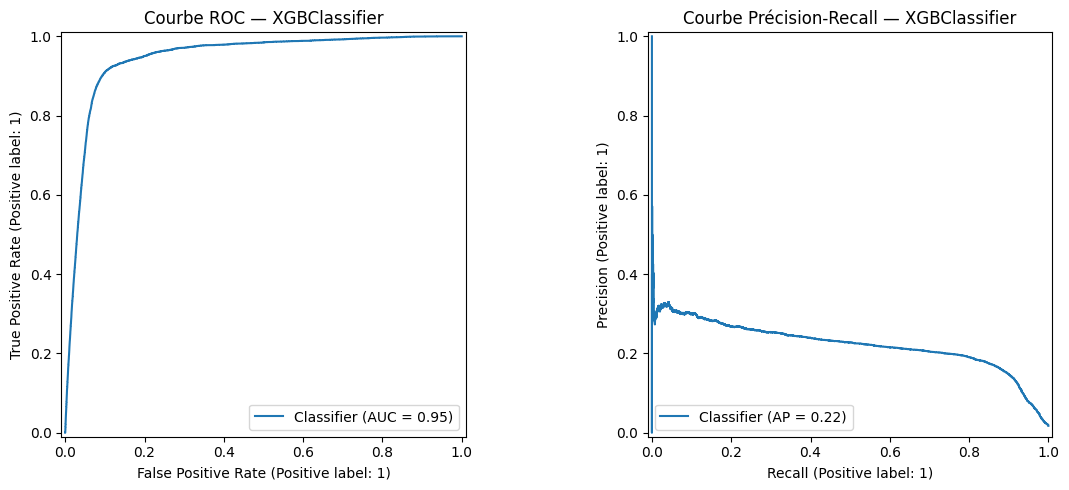

Modèle sauvegardé dans models/xgboost_tuned.pkl


'models/xgboost_tuned.pkl'

In [11]:
import pandas as pd
from xgboost import XGBClassifier
from src.model import FEATURES, split_data, evaluate, save_model

df = pd.read_csv('data/processed/panel_final.csv')
x_train, x_test, y_train, y_test = split_data(df)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

best_model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=1.0,
    min_child_weight=1,
    gamma=0,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
)

best_model.fit(x_train, y_train)
metrics = evaluate(best_model, x_test, y_test)
save_model(best_model, 'xgboost_tuned')